In [1]:
import pandas as pd
file_path = r"D:\current datset.csv"
df = pd.read_csv(file_path)
df.columns


Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'Deliveredcity', 'Deliver_state', 'SellerID'],
      dtype='object')

In [2]:
import pandas as pd
df.dtypes


OrderID           object
OrderDate         object
CustomerID        object
CustomerName      object
ProductID         object
ProductName       object
Category          object
Brand             object
Quantity           int64
UnitPrice        float64
Discount         float64
Tax              float64
ShippingCost     float64
TotalAmount      float64
PaymentMethod     object
OrderStatus       object
Deliveredcity     object
Deliver_state     object
SellerID          object
dtype: object

In [3]:
df.describe()


,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


In [4]:
df.isnull().sum()

OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
Deliveredcity    0
Deliver_state    0
SellerID         0
dtype: int64

In [5]:
#Label encoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['OrderStatus_Encoded'] = le.fit_transform(df['OrderStatus'])
df.head()


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,Deliveredcity,Deliver_state,SellerID,OrderStatus_Encoded
0,ORD0000001,31-01-2023,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,SELL01967,1
1,ORD0000002,30-12-2023,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,SELL01298,1
2,ORD0000003,10-05-2022,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,SELL00908,1
3,ORD0000004,18-07-2023,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,SELL01164,1
4,ORD0000005,04-02-2023,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,SELL01411,0


In [6]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
payment_list = ['Debit Card', 'Amazon Pay', 'Cash on Delivery', 'Credit Card', 'UPI', 'Net Banking']
ohe = OneHotEncoder(categories=[payment_list], sparse_output=False, handle_unknown='ignore')
encoded_data = ohe.fit_transform(df[['PaymentMethod']])
column_names = ohe.get_feature_names_out(['PaymentMethod'])
df = df.join(pd.DataFrame(encoded_data, columns=column_names, index=df.index))
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,Deliveredcity,Deliver_state,SellerID,OrderStatus_Encoded,PaymentMethod_Debit Card,PaymentMethod_Amazon Pay,PaymentMethod_Cash on Delivery,PaymentMethod_Credit Card,PaymentMethod_UPI,PaymentMethod_Net Banking
0,ORD0000001,31-01-2023,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,...,Washington,DC,SELL01967,1,1.0,0.0,0.0,0.0,0.0,0.0
1,ORD0000002,30-12-2023,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,...,Fort Worth,TX,SELL01298,1,0.0,1.0,0.0,0.0,0.0,0.0
2,ORD0000003,10-05-2022,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,...,Austin,TX,SELL00908,1,1.0,0.0,0.0,0.0,0.0,0.0
3,ORD0000004,18-07-2023,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,...,Charlotte,NC,SELL01164,1,0.0,0.0,1.0,0.0,0.0,0.0
4,ORD0000005,04-02-2023,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,...,San Antonio,TX,SELL01411,0,0.0,0.0,0.0,1.0,0.0,0.0


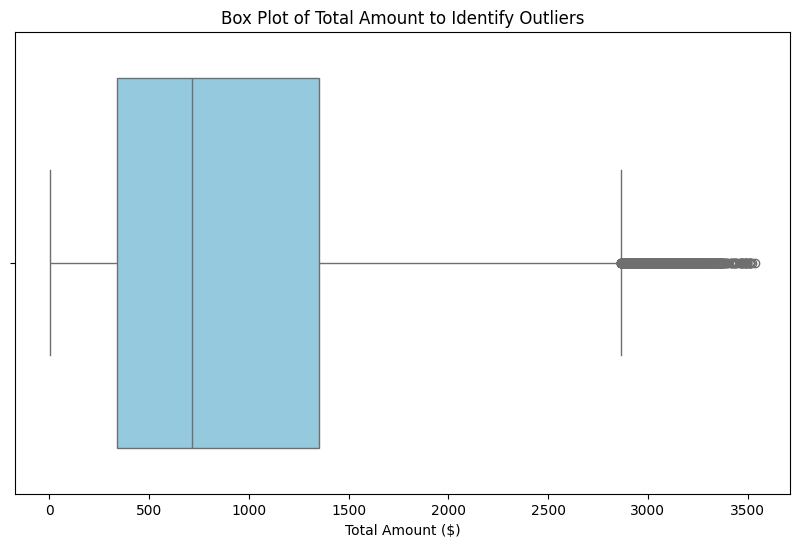

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
# Create the box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['TotalAmount'], color='skyblue')
# Add labels and title
plt.title('Box Plot of Total Amount to Identify Outliers')
plt.xlabel('Total Amount ($)')
plt.show()
